## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [2]:
EXPERIMENT_NAME='TL/05_inceptionv3_without_tl'
assert(not EXPERIMENT_NAME is None)

import tensorflow as tf
import uuid
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import warnings
import rasterio
import json
import glob
import shutil

# Reduce TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Activation, Rescaling
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import TerminateOnNaN, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

%matplotlib inline
print(tf.config.list_physical_devices('GPU'))

2026-01-09 13:24:29.671155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 13:24:29.678648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 13:24:29.687833: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 13:24:29.690688: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 13:24:29.697662: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1767965071.121700  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767965071.154620  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767965071.156467  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
PROJECT_PATH = "/workspace/COMPUTERVISIONPROYECT"
DATASET_NAME = 'stratified'

XVIEW_RECOGNITION_PATH = os.path.join(PROJECT_PATH, "data/xview_recognition")

EXPERIMENT_PATH = os.path.join(PROJECT_PATH, "experiment_results", EXPERIMENT_NAME)
EXPERIMENT_RESULTS = os.path.join(EXPERIMENT_PATH, "results")
assert(not os.path.exists(EXPERIMENT_PATH))
if not os.path.exists(EXPERIMENT_PATH):
    os.mkdir(EXPERIMENT_PATH)
    os.mkdir(EXPERIMENT_RESULTS)
CHECKPOINT_DIR = os.path.join(EXPERIMENT_PATH, 'model_checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_WEIGHTS_FILENAME_PATTERN = os.path.join(CHECKPOINT_DIR, 'epoch_{epoch:03d}-val_loss_{val_loss:.4f}.keras')
MODEL_PATH = os.path.join(EXPERIMENT_PATH, 'model.keras')

CM_PATH = os.path.join(EXPERIMENT_RESULTS, 'cm.png')
METRICS_PATH = os.path.join(EXPERIMENT_RESULTS, 'metrics.csv')
ACC_LOSS_PATH = os.path.join(EXPERIMENT_RESULTS, 'acc_loss.png')
TEST_PREDICTS_PATH = os.path.join(EXPERIMENT_RESULTS, 'prediction.json')
HISTORY_PATH = os.path.join(EXPERIMENT_RESULTS, 'history.csv')

TRAIN_SET_FILENAME = '_'.join([DATASET_NAME, 'train.tfrecord'])
VALIDATION_SET_FILENAME = '_'.join([DATASET_NAME, 'validation.tfrecord'])
TRAIN_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, TRAIN_SET_FILENAME)
VALIDATION_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, VALIDATION_SET_FILENAME)

# Tensorboard
LOG_DIR = os.path.join(EXPERIMENT_PATH, 'logs')
os.makedirs(LOG_DIR, exist_ok=True)

SYMLINK_PATH = os.path.join('/workspace', 'tensorboard_logs')
if os.path.islink(SYMLINK_PATH):
    os.unlink(SYMLINK_PATH)
os.symlink(LOG_DIR, SYMLINK_PATH)

## Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = None
DROPOUT_RATE = 0.5
REGULARIZER_PENALTY = None
EPOCHS = 20

categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

# Required classes and functions

In [4]:
class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [5]:
def draw_confusion_matrix(cm, categories, save_path=None, exp_name=None):
    # Draw confusion matrix
    fig = plt.figure(figsize=[3.2*pow(len(categories), 0.5), 2.4*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(15-pow(len(categories), 0.5)))
    fig.tight_layout()

    if save_path:
        if exp_name:
            plt.title(exp_name)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Gráfico guardado en: {save_path}")

    plt.show()

# 0. La usamos para las imágenes de test
def load_geoimage(filename_tensor):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    filename = filename_tensor
    src_raster = rasterio.open(filename, 'r')

    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

# 1. Función para decodificar los ejemplos del archivo
def _parse_image_function(example_proto):
    feature_description = {
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
        'depth': tf.io.FixedLenFeature([], tf.int64),
        'category_id': tf.io.FixedLenFeature([], tf.int64),
        'image_raw': tf.io.FixedLenFeature([], tf.string),
    }
    
    features = tf.io.parse_single_example(example_proto, feature_description)
    
    image = tf.io.decode_raw(features['image_raw'], out_type=tf.uint8)
    shape = [features['height'], features['width'], features['depth']]
    image = tf.reshape(image, shape)
    image = tf.cast(image, tf.float32)
    
    image = tf.image.resize(image, [224, 224])
    
    category_id = tf.cast(features['category_id'], tf.int32)
    label = tf.one_hot(category_id, depth=len(categories))
    
    return image, label

# 2. Función para crear el dataset
def create_tfrecord_dataset(filenames, batch_size, do_shuffle=False):
    # Lee los archivos TFRecord. Puede leer de múltiples archivos en paralelo.
    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=tf.data.AUTOTUNE)
    
    dataset = dataset.map(_parse_image_function, num_parallel_calls=tf.data.AUTOTUNE)
    # dataset = dataset.cache()
    
    if do_shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Datasets definition

In [6]:
train_dataset = create_tfrecord_dataset([TRAIN_SET_PATH], BATCH_SIZE, do_shuffle=True)
valid_dataset = create_tfrecord_dataset([VALIDATION_SET_PATH], BATCH_SIZE)

I0000 00:00:1767965071.337711  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767965071.339974  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767965071.341486  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767965071.457503  253862 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [7]:
y_train_labels = []
for _,label_idxs in train_dataset:
    y_train_labels += list(label_idxs.numpy().argmax(axis=1))

index,freqs = np.unique(y_train_labels, return_counts=True)
categories_count = pd.Series(freqs, index=[categories[idx] for idx in index], name='Size').sort_values(ascending=False)

categories_count

2026-01-09 13:24:34.403015: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Building              3235
Small car             2992
Truck                 1989
Bus                   1591
Shipping container    1371
Storage tank          1322
Dump truck            1112
Motorboat              962
Excavator              710
Fishing vessel         635
Cargo plane            571
Pylon                  281
Helipad                100
Name: Size, dtype: int64

# Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [8]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = True


model = Sequential(name=EXPERIMENT_NAME)
model.add(base_model)
model.add(Flatten(name='Flatten'))

model.add(Dense(256, activation='relu'))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(len(categories), activation='softmax'))

model.summary()

Model: "TL/05_inceptionv3_without_tl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 Flatten (Flatten)           (None, 51200)             0         
                                                                 
 dense (Dense)               (None, 256)               13107456  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 13)                3341      
                                                                 
Total params: 34913581 (133.18 MB)
Trainable params: 34879149 (133.05 MB)
Non-trainable params: 34432 (134.50 KB)
________________________________________________________

In [9]:
opt = Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Callbacks
model_checkpoint = ModelCheckpoint(
    filepath=BEST_WEIGHTS_FILENAME_PATTERN,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True
)

tensorboard_callback = TensorBoard(
    log_dir=LOG_DIR,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch',
    profile_batch=0
)

reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
terminate = TerminateOnNaN()
early_stop = EarlyStopping('val_accuracy', patience=EPOCHS, verbose=1, restore_best_weights=False)
callbacks = [reduce_lr, early_stop, terminate, model_checkpoint, tensorboard_callback]

In [11]:
print('Training model')
h = model.fit(train_dataset, 
              validation_data=valid_dataset, 
              epochs=EPOCHS, 
              callbacks=callbacks, 
              verbose=1)

history_df = pd.DataFrame(model.history.history).reset_index(names=['epoch'])
history_df['checkpoint'] = False

checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, '*.keras'))

if checkpoints:
    # Copiamos el mejor modelo en la ruta {EXPERIMENT_PATH}/model.keras
    # Ordenar los archivos por el valor de 'val_loss' (que está en el nombre)
    # y coger el primero (el que tenga el valor más bajo)
    BEST_WEIGHTS_FILENAME = min(checkpoints, key=lambda x: float(x.split('val_loss_')[1].replace('.keras', '')))
    model.load_weights(BEST_WEIGHTS_FILENAME)
    model.save(MODEL_PATH)

    print(f"El mejor modelo se encuentra en: {MODEL_PATH}")
else:
    print("No se encontraron checkpoints.")

history_df.to_csv(HISTORY_PATH, index=False)
print(f"El historial se encuentra en: {HISTORY_PATH}")

Training model


'''+ptx85+ptx85' is not a recognized feature for this target+ptx85' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
' is not a recognized feature for this target'' (ignoring feature)
+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/20


2026-01-09 13:24:44.750248: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1767965084.787439  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.789281  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.795874  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.796219  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.796627  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.797159  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.803036  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965084.803857  253958 gpu_

      1/Unknown - 20s 20s/step - loss: 3.2370 - accuracy: 0.0625

...

    264/Unknown - 49s 108ms/step - loss: 2.8387 - accuracy: 0.1795

W0000 00:00:1767965124.750684  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.752495  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.755743  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.764068  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.789465  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.790408  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.791189  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.792019  253958 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965124.793158  253958 gp


Epoch 1: val_loss improved from inf to 2.31468, saving model to /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/05_inceptionv3_without_tl/model_checkpoints/epoch_001-val_loss_2.3147.keras


W0000 00:00:1767965127.487852  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.487935  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.487982  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488035  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488165  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488240  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488305  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488374  253952 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965127.488452  253952 gp

264/264 [==============================] - 55s 133ms/step - loss: 2.8387 - accuracy: 0.1795 - val_loss: 2.3147 - val_accuracy: 0.2395 - lr: 0.0010
Epoch 2/20
264/264 [==============================] - ETA: 0s - loss: 2.1715 - accuracy: 0.2740
Epoch 2: val_loss improved from 2.31468 to 2.04587, saving model to /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/05_inceptionv3_without_tl/model_checkpoints/epoch_002-val_loss_2.0459.keras
264/264 [==============================] - 32s 119ms/step - loss: 2.1715 - accuracy: 0.2740 - val_loss: 2.0459 - val_accuracy: 0.2928 - lr: 0.0010
Epoch 3/20
264/264 [==============================] - ETA: 0s - loss: 2.0874 - accuracy: 0.2994
Epoch 3: val_loss did not improve from 2.04587
264/264 [==============================] - 32s 121ms/step - loss: 2.0874 - accuracy: 0.2994 - val_loss: 2.0698 - val_accuracy: 0.2891 - lr: 0.0010
Epoch 4/20
264/264 [==============================] - ETA: 0s - loss: 1.9750 - accuracy: 0.3308
Epoch 4: val_loss improve

# Validation
Compute validation metrics.

In [12]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "TL/05_inceptionv3_without_tl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 Flatten (Flatten)           (None, 51200)             0         
                                                                 
 dense (Dense)               (None, 256)               13107456  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 13)                3341      
                                                                 
Total params: 34913581 (133.18 MB)
Trainable params: 34879149 (133.05 MB)
Non-trainable params: 34432 (134.50 KB)
________________________________________________________

In [13]:
predictions = model.predict(valid_dataset)
category_names = np.array(list(categories.values()))
y_pred = category_names[predictions.argmax(axis=1)]

y_true = []

for images_batch, labels_batch in valid_dataset:
    labels_np = labels_batch.numpy()
    
    true_indices = np.argmax(labels_np, axis=1)
    batch_labels = category_names[true_indices]
    
    y_true.extend(batch_labels)

30/30 [==============================] - 2s 24ms/step


2026-01-09 13:37:10.580431: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Gráfico guardado en: /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/05_inceptionv3_without_tl/results/cm.png


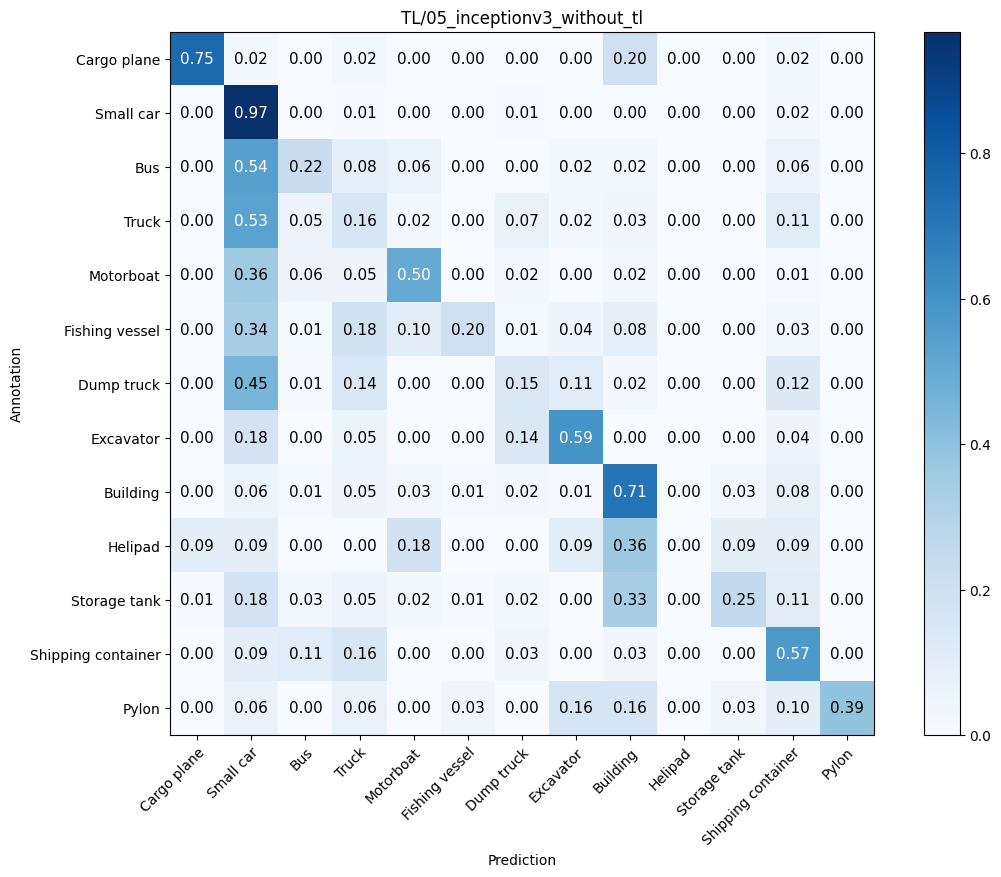

In [14]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories, CM_PATH, EXPERIMENT_NAME)

In [15]:
ll = []
# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
global_acc = acc.mean()
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
global_recall = acc.mean()
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
global_precision = acc.mean()
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    ll.append(pd.Series([recall, precision, specificity, f1_score], name=categories[idx], index=["Recall", "Precision", "Specificity", "F1 Score"]))
ll = pd.DataFrame(ll)
sizes_col=pd.Series(y_true).value_counts()
sizes_col.name="Size"
ll = pd.concat([sizes_col, ll, pd.Series([EXPERIMENT_NAME for _ in categories], name='Experiment', index=categories.values())],axis=1)
ll.index.name='Category'
ll = ll.reset_index().set_index(['Experiment','Category'])
ll['Accuracy'] = np.nan
ll.loc[(EXPERIMENT_NAME, 'Global'), ['Size', 'Recall', 'Precision', 'Accuracy']] = [ll.Size.sum().astype(int), global_recall, global_precision, global_acc]
ll = ll.sort_values('Size', ascending=False)
ll.to_csv(METRICS_PATH)
ll.transpose()

Mean Accuracy: 51.520%
Mean Recall: 41.920%
Mean Precision: 55.504%


Experiment  TL/05_inceptionv3_without_tl                                      \
Category                          Global    Building   Small car       Truck   
Size                         1875.000000  359.000000  332.000000  221.000000   
Recall                          0.555045    0.710306    0.966867    0.158371   
Precision                       0.555045    0.722380    0.439124    0.246479   
Specificity                          NaN    0.935356    0.734284    0.935308   
F1 Score                             NaN    0.716292    0.603951    0.192837   
Accuracy                        0.419204         NaN         NaN         NaN   

Experiment                                                           \
Category            Bus Shipping container Storage tank  Dump truck   
Size         177.000000         152.000000   147.000000  124.000000   
Recall         0.220339           0.572368     0.251701    0.145161   
Precision      0.458824           0.437186     0.770833    0.281250   
Specificity    0.972909           0.934997     0.993634    0.973729   
F1 Score       0.297710           0.495726     0.379487    0.191489   
Accuracy            NaN                NaN          NaN         NaN   

Experiment                                                                \
Category      Motorboat  Excavator Fishing vessel Cargo plane      Pylon   
Size         107.000000  79.000000      71.000000   64.000000  31.000000   
Recall         0.495327   0.594937       0.197183    0.750000   0.387097   
Precision      0.582418   0.580247       0.736842    0.960000   1.000000   
Specificity    0.978507   0.981069       0.997228    0.998896   1.000000   
F1 Score       0.535354   0.587500       0.311111    0.842105   0.558140   
Accuracy            NaN        NaN            NaN         NaN        NaN   

Experiment           
Category    Helipad  
Size           11.0  
Recall          0.0  
Precision       0.0  
Specificity     1.0  
F1 Score        0.0  
Accuracy        NaN

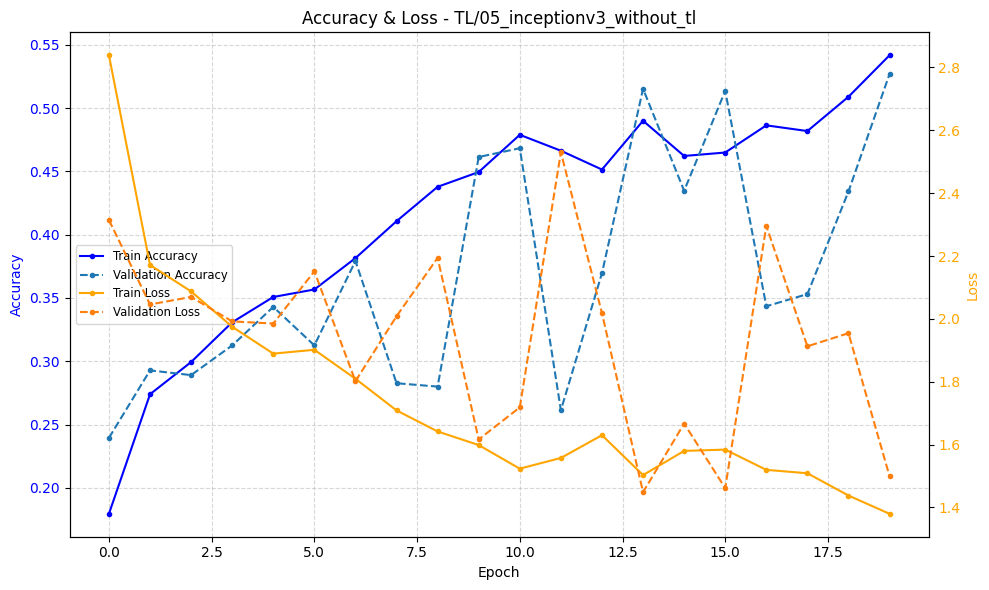

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title(f'Accuracy & Loss - {EXPERIMENT_NAME}')
ax1.set_xlabel('Epoch')

color_acc = 'blue'
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.plot(h.history['accuracy'], label='Train Accuracy', color='blue', marker='.')
ax1.plot(h.history['val_accuracy'], label='Validation Accuracy', color='tab:blue', linestyle='--', marker='.')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color_loss = 'orange'
ax2.set_ylabel('Loss', color=color_loss)
ax2.plot(h.history['loss'], label='Train Loss', color='orange', marker='.')
ax2.plot(h.history['val_loss'], label='Validation Loss', color='tab:orange', linestyle='--', marker='.')
ax2.tick_params(axis='y', labelcolor=color_loss)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', frameon=True, fontsize='small')

fig.tight_layout()

plt.savefig(ACC_LOSS_PATH, bbox_inches='tight', dpi=300)

plt.show()

# Testing
Try to improve the results provided in the competition.

In [17]:
anns = []
for (dirpath, dirnames, filenames) in os.walk(os.path.join(XVIEW_RECOGNITION_PATH, 'xview_test')):
    for filename in filenames:
        image = GenericImage(os.path.join(dirpath,filename))
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [18]:
model = tf.keras.models.load_model(MODEL_PATH)
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

W0000 00:00:1767965862.100012  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100058  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100078  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100102  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100140  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100171  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100209  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100245  253954 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767965862.100290  253954 gp

In [19]:
with open(TEST_PREDICTS_PATH, "w") as outfile:
    json.dump(predictions_data, outfile)